## Lưu ý phương pháp

Dữ liệu thực tế chỉ gồm Q1/2025 và Q1/2026, không có chuỗi liên tục 15 tháng. Vì vậy nhóm không sử dụng ETS/Prophet/ARIMA làm mô hình chính vì không đủ dữ liệu để học mùa vụ tháng.

Mô hình sử dụng là limited-data forecasting:
- Tổng Q2/2026: run-rate Q1/2026 theo kịch bản.
- Sản phẩm/SKU: phân bổ theo tỷ trọng Q1/2026 kết hợp Q1/2025.
- Màu sắc: dự báo theo cơ cấu Q1/2026 và thay đổi tỷ trọng YoY.
- Đại lý: propensity proxy bằng RFM, recency, hoạt động Q1/2026 và YoY trend.

Kết quả dùng để hỗ trợ quyết định kinh doanh, không phải cam kết chính xác tuyệt đối.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

DATA_PATH = Path(
    "/kaggle/input/datasets/linhdan21nguyen/tnbike-forecast-q1-2025-q1-2026/v_fact_sales_dashboard_q1_2025_q1_2026_train.csv"
)

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Không tìm thấy file: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

df["order_date"] = pd.to_datetime(df["order_date"])
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["year_month"] = df["order_date"].dt.to_period("M").astype(str)

print("Đang dùng file:", DATA_PATH)
print("Shape:", df.shape)
display(df.head())

Đang dùng file: /kaggle/input/datasets/linhdan21nguyen/tnbike-forecast-q1-2025-q1-2026/v_fact_sales_dashboard_q1_2025_q1_2026_train.csv
Shape: (25754, 25)


,order_date,fiscal_year,fiscal_quarter,fiscal_month,week_of_year,so_number,customer_code_final,customer_name_final,customer_mapping_status,province_name_final,...,line_name_final,group_code_final,group_name_final,product_classification_status,quantity,unit_price,line_total,year,month,year_month
0,2025-01-02,2025,1,1,1,BH25.0001,KH-00001,HỘ KINH DOANH TÚ ANH,MAPPED,Hà Nội,...,Xe GN 05-26,CITYBIKE_P,Xe phổ thông,MASTER_DATA,1.0,2305555.56,2305556.0,2025,1,2025-01
1,2025-01-06,2025,1,1,2,BH25.0002,KH-00002,CÔNG TY TNHH THƯƠNG MẠI VIỆT ANH,MAPPED,Hà Nội,...,Xe Super 26,SPORTBIKE_S,Xe thể thao thép,MASTER_DATA,1.0,3509259.26,3509259.0,2025,1,2025-01
2,2025-01-06,2025,1,1,2,BH25.0003,KH-00003,CÔNG TY CỔ PHẦN THƯƠNG MẠI NAM TIẾN,MAPPED,Hà Nội,...,Xe New 24,CITYBIKE_P,Xe phổ thông,MASTER_DATA,1.0,2398148.15,2398148.0,2025,1,2025-01
3,2025-01-06,2025,1,1,2,BH25.0004,KH-00004,DOANH NGHIỆP TW KHẢI HOÀN,MAPPED,Hải Phòng,...,Xe GN 06-26 2.0,CITYBIKE_P,Xe phổ thông,MASTER_DATA,5.0,2453703.70,12268519.0,2025,1,2025-01
4,2025-01-07,2025,1,1,2,BH25.0005,KH-00005,CÔNG TY TNHH ĐẠI LỢI,MAPPED,Hà Nội,...,Xe GN 06-26,CITYBIKE_P,Xe phổ thông,MASTER_DATA,2.0,2212962.96,4425926.0,2025,1,2025-01


In [2]:
required_cols = [
    "order_date",
    "so_number",
    "customer_code_final",
    "customer_name_final",
    "province_name_final",
    "region_final",
    "product_code",
    "product_name",
    "color",
    "line_name_final",
    "group_name_final",
    "quantity",
    "line_total"
]

missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:
    raise ValueError(f"Thiếu cột bắt buộc: {missing_cols}")

summary_month = (
    df.groupby(["year", "month", "year_month"])
    .agg(
        rows=("so_number", "size"),
        orders=("so_number", "nunique"),
        quantity=("quantity", "sum"),
        revenue=("line_total", "sum")
    )
    .reset_index()
    .sort_values(["year", "month"])
)

display(summary_month)

print("Số dòng:", len(df))
print("Số đơn:", df["so_number"].nunique())
print("Số SKU:", df["product_code"].nunique())
print("Số đại lý:", df["customer_code_final"].nunique())
print("Min date:", df["order_date"].min())
print("Max date:", df["order_date"].max())
print("Số tháng có dữ liệu:", df["year_month"].nunique())
print("Các tháng có dữ liệu:", sorted(df["year_month"].unique()))

,year,month,year_month,rows,orders,quantity,revenue
0,2025,1,2025-01,339,61,1837.0,3.198170e+09
1,2025,2,2025-02,1892,185,5030.0,6.337211e+09
2,2025,3,2025-03,5184,447,14609.0,1.858179e+10
3,2026,1,2026-01,4778,482,12541.0,2.113507e+10
4,2026,2,2026-02,4838,452,12522.0,1.938887e+10
5,2026,3,2026-03,8723,1132,25607.0,4.080405e+10


Số dòng: 25754
Số đơn: 2759
Số SKU: 265
Số đại lý: 703
Min date: 2025-01-02 00:00:00
Max date: 2026-03-31 00:00:00
Số tháng có dữ liệu: 6
Các tháng có dữ liệu: ['2025-01', '2025-02', '2025-03', '2026-01', '2026-02', '2026-03']


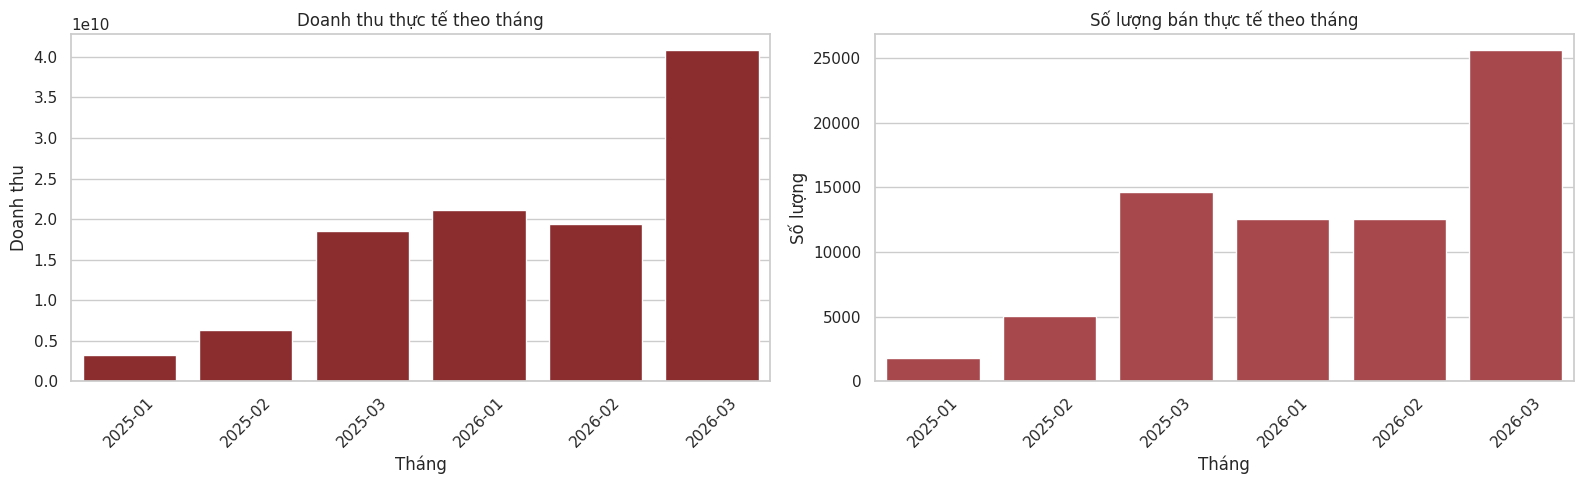

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(
    data=summary_month,
    x="year_month",
    y="revenue",
    color="#9b1c1f",
    ax=axes[0]
)
axes[0].set_title("Doanh thu thực tế theo tháng")
axes[0].set_xlabel("Tháng")
axes[0].set_ylabel("Doanh thu")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(
    data=summary_month,
    x="year_month",
    y="quantity",
    color="#b63a3d",
    ax=axes[1]
)
axes[1].set_title("Số lượng bán thực tế theo tháng")
axes[1].set_xlabel("Tháng")
axes[1].set_ylabel("Số lượng")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [4]:
q1_2025 = df[df["year"] == 2025].copy()
q1_2026 = df[df["year"] == 2026].copy()

rev_2025 = q1_2025["line_total"].sum()
rev_2026 = q1_2026["line_total"].sum()

qty_2025 = q1_2025["quantity"].sum()
qty_2026 = q1_2026["quantity"].sum()

orders_2025 = q1_2025["so_number"].nunique()
orders_2026 = q1_2026["so_number"].nunique()

revenue_yoy = rev_2026 / rev_2025 - 1
quantity_yoy = qty_2026 / qty_2025 - 1
orders_yoy = orders_2026 / orders_2025 - 1

yoy_summary = pd.DataFrame({
    "metric": ["Revenue", "Quantity", "Orders"],
    "q1_2025": [rev_2025, qty_2025, orders_2025],
    "q1_2026": [rev_2026, qty_2026, orders_2026],
    "yoy_growth": [revenue_yoy, quantity_yoy, orders_yoy]
})

display(yoy_summary)

print("YoY revenue growth:", f"{revenue_yoy:.2%}")
print("YoY quantity growth:", f"{quantity_yoy:.2%}")
print("YoY orders growth:", f"{orders_yoy:.2%}")

,metric,q1_2025,q1_2026,yoy_growth
0,Revenue,2.811717e+10,8.132799e+10,1.892467
1,Quantity,2.147600e+04,5.067000e+04,1.359378
2,Orders,6.930000e+02,2.066000e+03,1.981241


YoY revenue growth: 189.25%
YoY quantity growth: 135.94%
YoY orders growth: 198.12%


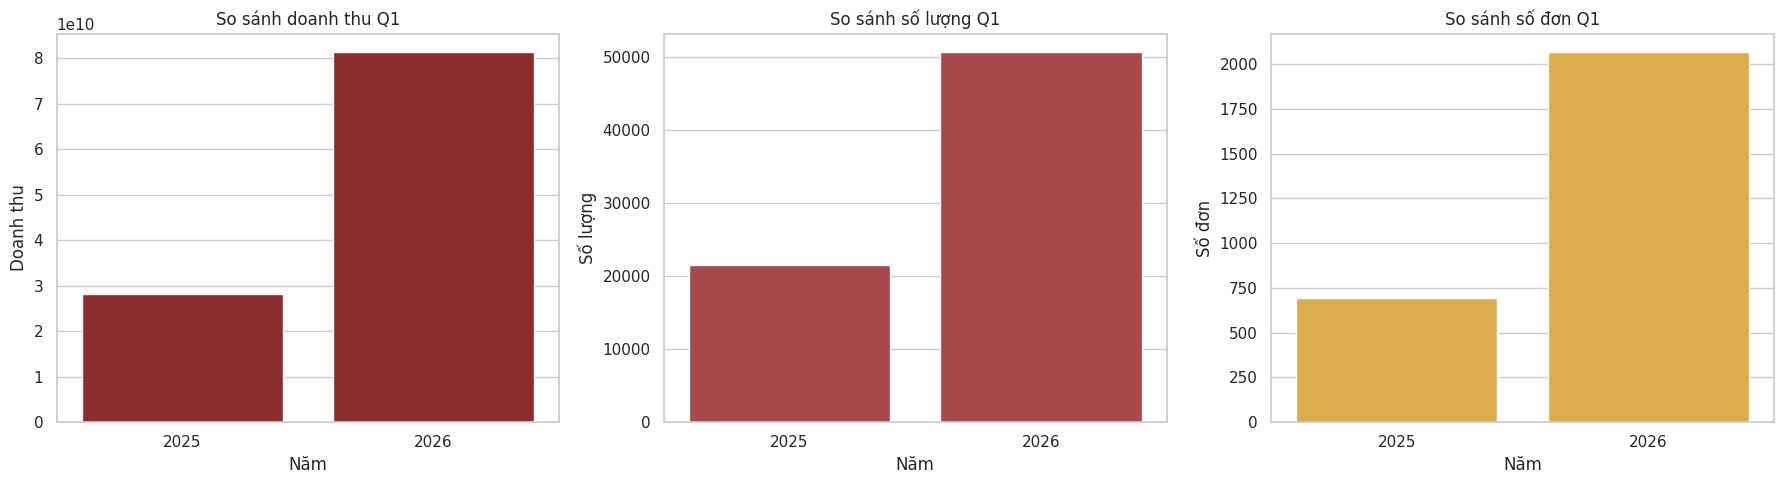

In [5]:
compare_q1 = pd.DataFrame({
    "year": ["2025", "2026"],
    "revenue": [rev_2025, rev_2026],
    "quantity": [qty_2025, qty_2026],
    "orders": [orders_2025, orders_2026]
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=compare_q1, x="year", y="revenue", color="#9b1c1f", ax=axes[0])
axes[0].set_title("So sánh doanh thu Q1")
axes[0].set_xlabel("Năm")
axes[0].set_ylabel("Doanh thu")

sns.barplot(data=compare_q1, x="year", y="quantity", color="#b63a3d", ax=axes[1])
axes[1].set_title("So sánh số lượng Q1")
axes[1].set_xlabel("Năm")
axes[1].set_ylabel("Số lượng")

sns.barplot(data=compare_q1, x="year", y="orders", color="#f2b632", ax=axes[2])
axes[2].set_title("So sánh số đơn Q1")
axes[2].set_xlabel("Năm")
axes[2].set_ylabel("Số đơn")

plt.tight_layout()
plt.show()

In [6]:
base_monthly_revenue = rev_2026 / 3
base_monthly_quantity = qty_2026 / 3
base_monthly_orders = orders_2026 / 3

forecast_q2 = pd.DataFrame({
    "forecast_month": ["2026-04", "2026-05", "2026-06"],
    "base_revenue": [base_monthly_revenue] * 3,
    "base_quantity": [base_monthly_quantity] * 3,
    "base_orders": [base_monthly_orders] * 3
})

# Không có dữ liệu cùng kỳ Q2/2025 để học mùa vụ, nên dùng run-rate Q1/2026 làm baseline và biên kịch bản +/- 10%.
scenario_margin = 0.10

forecast_q2["conservative_revenue"] = forecast_q2["base_revenue"] * (1 - scenario_margin)
forecast_q2["optimistic_revenue"] = forecast_q2["base_revenue"] * (1 + scenario_margin)

forecast_q2["conservative_quantity"] = forecast_q2["base_quantity"] * (1 - scenario_margin)
forecast_q2["optimistic_quantity"] = forecast_q2["base_quantity"] * (1 + scenario_margin)

forecast_q2["conservative_orders"] = forecast_q2["base_orders"] * (1 - scenario_margin)
forecast_q2["optimistic_orders"] = forecast_q2["base_orders"] * (1 + scenario_margin)

display(forecast_q2)

,forecast_month,base_revenue,base_quantity,base_orders,conservative_revenue,optimistic_revenue,conservative_quantity,optimistic_quantity,conservative_orders,optimistic_orders
0,2026-04,2.710933e+10,16890.0,688.666667,2.439840e+10,2.982026e+10,15201.0,18579.0,619.8,757.533333
1,2026-05,2.710933e+10,16890.0,688.666667,2.439840e+10,2.982026e+10,15201.0,18579.0,619.8,757.533333
2,2026-06,2.710933e+10,16890.0,688.666667,2.439840e+10,2.982026e+10,15201.0,18579.0,619.8,757.533333


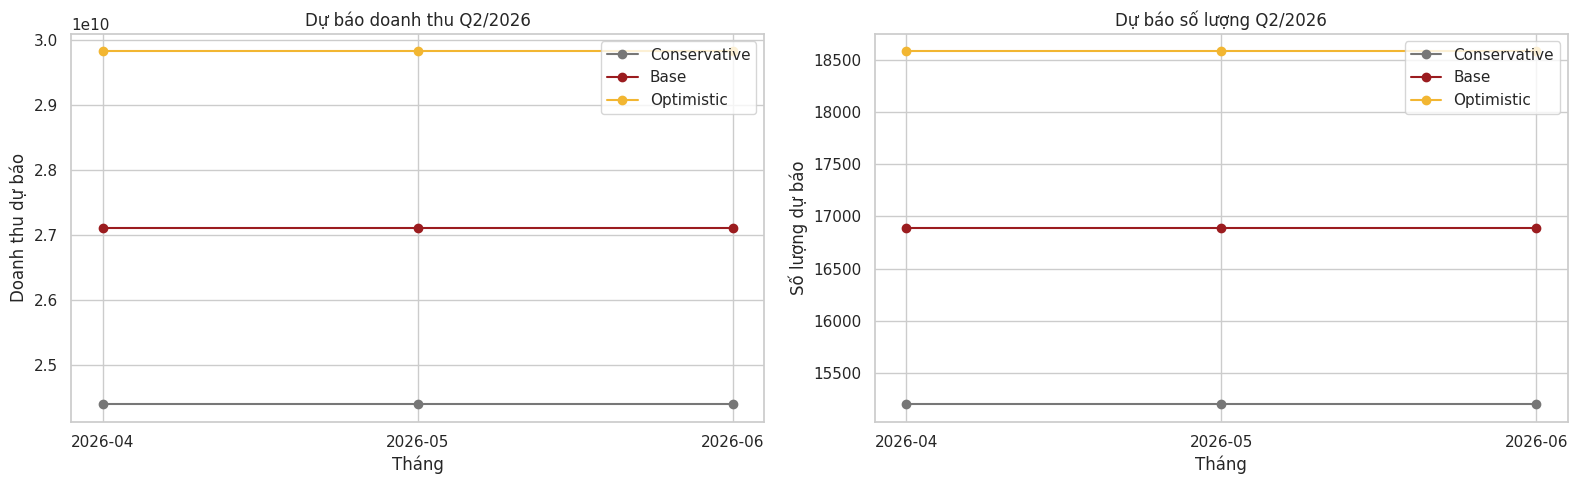

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(forecast_q2["forecast_month"], forecast_q2["conservative_revenue"], marker="o", label="Conservative", color="#777777")
axes[0].plot(forecast_q2["forecast_month"], forecast_q2["base_revenue"], marker="o", label="Base", color="#9b1c1f")
axes[0].plot(forecast_q2["forecast_month"], forecast_q2["optimistic_revenue"], marker="o", label="Optimistic", color="#f2b632")
axes[0].set_title("Dự báo doanh thu Q2/2026")
axes[0].set_xlabel("Tháng")
axes[0].set_ylabel("Doanh thu dự báo")
axes[0].legend()

axes[1].plot(forecast_q2["forecast_month"], forecast_q2["conservative_quantity"], marker="o", label="Conservative", color="#777777")
axes[1].plot(forecast_q2["forecast_month"], forecast_q2["base_quantity"], marker="o", label="Base", color="#9b1c1f")
axes[1].plot(forecast_q2["forecast_month"], forecast_q2["optimistic_quantity"], marker="o", label="Optimistic", color="#f2b632")
axes[1].set_title("Dự báo số lượng Q2/2026")
axes[1].set_xlabel("Tháng")
axes[1].set_ylabel("Số lượng dự báo")
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
sku_q1_2026 = (
    q1_2026.groupby(
        ["product_code", "product_name", "line_name_final", "group_name_final","color"],
        dropna=False
    )
    .agg(
        q1_quantity=("quantity", "sum"),
        q1_revenue=("line_total", "sum")
    )
    .reset_index()
)

sku_q1_2025 = (
    q1_2025.groupby("product_code", dropna=False)
    .agg(
        q1_2025_quantity=("quantity", "sum"),
        q1_2025_revenue=("line_total", "sum")
    )
    .reset_index()
)

sku_forecast = sku_q1_2026.merge(sku_q1_2025, on="product_code", how="left")

sku_forecast[["q1_2025_quantity", "q1_2025_revenue"]] = (
    sku_forecast[["q1_2025_quantity", "q1_2025_revenue"]].fillna(0)
)

sku_forecast["yoy_qty_growth"] = (
    (sku_forecast["q1_quantity"] + 1)
    / (sku_forecast["q1_2025_quantity"] + 1)
    - 1
)

# Chỉ dùng một phần momentum để tránh phóng đại vì thiếu dữ liệu Q2/2025
sku_forecast["momentum_factor"] = 1 + 0.25 * sku_forecast["yoy_qty_growth"].clip(-0.5, 1.0)

sku_forecast["share_rev_2026"] = sku_forecast["q1_revenue"] / sku_forecast["q1_revenue"].sum()
sku_forecast["share_qty_2026"] = sku_forecast["q1_quantity"] / sku_forecast["q1_quantity"].sum()

sku_forecast["share_rev_2025"] = sku_forecast["q1_2025_revenue"] / sku_forecast["q1_2025_revenue"].sum()
sku_forecast["share_qty_2025"] = sku_forecast["q1_2025_quantity"] / sku_forecast["q1_2025_quantity"].sum()

sku_forecast[["share_rev_2025", "share_qty_2025"]] = (
    sku_forecast[["share_rev_2025", "share_qty_2025"]].fillna(0)
)

sku_forecast["blend_rev_share"] = 0.7 * sku_forecast["share_rev_2026"] + 0.3 * sku_forecast["share_rev_2025"]
sku_forecast["blend_qty_share"] = 0.7 * sku_forecast["share_qty_2026"] + 0.3 * sku_forecast["share_qty_2025"]

sku_forecast["blend_rev_share"] = sku_forecast["blend_rev_share"] / sku_forecast["blend_rev_share"].sum()
sku_forecast["blend_qty_share"] = sku_forecast["blend_qty_share"] / sku_forecast["blend_qty_share"].sum()

q2_base_revenue = forecast_q2["base_revenue"].sum()
q2_base_quantity = forecast_q2["base_quantity"].sum()

sku_forecast["forecast_q2_revenue"] = q2_base_revenue * sku_forecast["blend_rev_share"]
sku_forecast["forecast_q2_quantity"] = q2_base_quantity * sku_forecast["blend_qty_share"]

sku_forecast["sku_trend"] = np.select(
    [
        (sku_forecast["q1_2025_quantity"] == 0) & (sku_forecast["q1_quantity"] > 0),
        sku_forecast["yoy_qty_growth"] > 0.1,
        sku_forecast["yoy_qty_growth"] < -0.1
    ],
    ["NEW_OR_RETURNED", "TĂNG", "GIẢM"],
    default="ỔN ĐỊNH"
)

sku_forecast["slow_mover_risk"] = np.where(
    (sku_forecast["q1_quantity"] < 5) | (sku_forecast["yoy_qty_growth"] < -0.2),
    "HIGH",
    "LOW"
)

top20_sku = sku_forecast.sort_values("forecast_q2_revenue", ascending=False).head(20)

print("Check tổng revenue SKU:", sku_forecast["forecast_q2_revenue"].sum())
print("Tổng Q2 base:", q2_base_revenue)

display(top20_sku)

Check tổng revenue SKU: 81327989876.0
Tổng Q2 base: 81327989876.0


,product_code,product_name,line_name_final,group_name_final,color,q1_quantity,q1_revenue,q1_2025_quantity,q1_2025_revenue,yoy_qty_growth,...,share_rev_2026,share_qty_2026,share_rev_2025,share_qty_2025,blend_rev_share,blend_qty_share,forecast_q2_revenue,forecast_q2_quantity,sku_trend,slow_mover_risk
89,000225002023000,Xe đạp Thống Nhất New 26 Kem,Xe New 26,Xe phổ thông,Kem,2460.0,3.962383e+09,1303.0,1.619322e+09,0.887270,...,0.048721,0.048549,0.066029,0.068138,0.053914,0.054426,4.384680e+09,2757.763374,TĂNG,LOW
77,000224002023000,Xe đạp Thống Nhất New 24 Kem,Xe New 24,Xe phổ thông,Kem,1742.0,2.612978e+09,796.0,9.170420e+08,1.186951,...,0.032129,0.034379,0.037393,0.041625,0.033708,0.036553,2.741420e+09,1852.145699,TĂNG,LOW
95,000226003023000,Xe đạp Thống Nhất LD 24-01_2023 Kem,Xe LD 24-01_2023,Xe phổ thông,Kem,1462.0,2.422159e+09,524.0,6.933593e+08,1.786667,...,0.029783,0.028853,0.028272,0.027402,0.029330,0.028418,2.385312e+09,1439.931088,TĂNG,LOW
87,000225002015000,Xe đạp Thống Nhất New 26 Café/nâu,Xe New 26,Xe phổ thông,Café/nâu,1303.0,2.098664e+09,663.0,8.493783e+08,0.963855,...,0.025805,0.025715,0.034634,0.034670,0.028454,0.028402,2.314085e+09,1439.123114,TĂNG,LOW
80,000225002002000,Xe đạp Thống Nhất New 26 Trắng,Xe New 26,Xe phổ thông,Trắng,1145.0,1.926264e+09,673.0,8.915628e+08,0.700297,...,0.023685,0.022597,0.036354,0.035193,0.027486,0.026376,2.235372e+09,1336.472180,TĂNG,LOW
57,000217003001000,Xe đạp Thống Nhất GN 06-26 2.0 Đen,Xe GN 06-26 2.0,Xe phổ thông,Đen,1367.0,2.206185e+09,496.0,6.404559e+08,1.752515,...,0.027127,0.026978,0.026115,0.025937,0.026823,0.026666,2.181499e+09,1351.173702,TĂNG,LOW
100,000230002023000,Xe đạp Thống Nhất LD 26 Kem,Xe LD 26,Xe phổ thông,Kem,1648.0,2.890632e+09,0.0,0.000000e+00,1648.000000,...,0.035543,0.032524,0.000000,0.000000,0.024880,0.022767,2.023443e+09,1153.600000,NEW_OR_RETURNED,LOW
27,000125002009000,Xe đạp Thống Nhất Puppy 20 Hồng,Xe Puppy 20,Xe trẻ em nhóm 1,Hồng,1480.0,1.893008e+09,466.0,5.432739e+08,2.171306,...,0.023276,0.029209,0.022153,0.024369,0.022939,0.027757,1.865591e+09,1406.426502,TĂNG,LOW
59,000217003008000,Xe đạp Thống Nhất GN 06-26 2.0 Ghi,Xe GN 06-26 2.0,Xe phổ thông,Ghi,1085.0,1.711430e+09,397.0,4.991782e+08,1.728643,...,0.021044,0.021413,0.020354,0.020760,0.020837,0.021217,1.694617e+09,1075.077943,TĂNG,LOW
91,000225002025000,Xe đạp Thống Nhất New 26 Xanh mint,Xe New 26,Xe phổ thông,Xanh mint,774.0,1.236815e+09,474.0,5.849526e+08,0.631579,...,0.015208,0.015275,0.023852,0.024787,0.017801,0.018129,1.447721e+09,918.585755,TĂNG,LOW


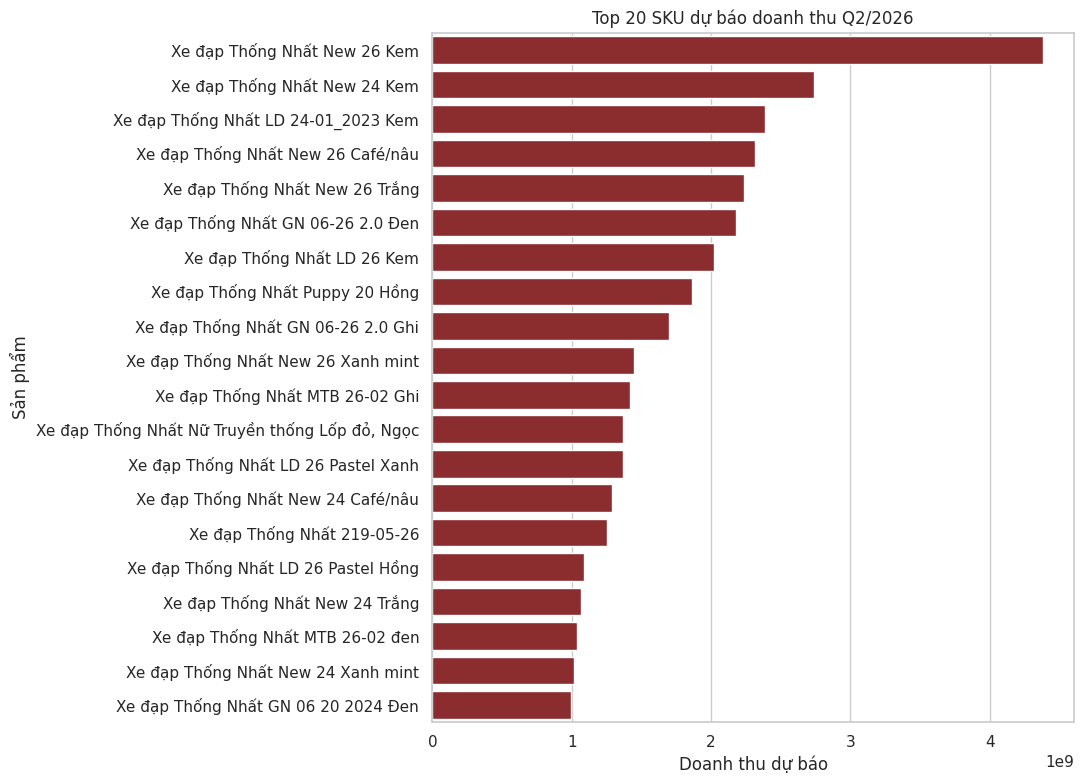

In [9]:
plt.figure(figsize=(11, 8))

sns.barplot(
    data=top20_sku,
    y="product_name",
    x="forecast_q2_revenue",
    color="#9b1c1f"
)

plt.title("Top 20 SKU dự báo doanh thu Q2/2026")
plt.xlabel("Doanh thu dự báo")
plt.ylabel("Sản phẩm")
plt.tight_layout()
plt.show()

In [10]:
group_forecast = (
    sku_forecast.groupby("group_name_final", dropna=False)
    .agg(
        forecast_q2_quantity=("forecast_q2_quantity", "sum"),
        forecast_q2_revenue=("forecast_q2_revenue", "sum"),
        sku_count=("product_code", "nunique")
    )
    .reset_index()
    .sort_values("forecast_q2_revenue", ascending=False)
)

display(group_forecast)

,group_name_final,forecast_q2_quantity,forecast_q2_revenue,sku_count
1,Xe phổ thông,32041.572944,5.174725e+10,66
4,Xe trẻ em nhóm 1,7499.362401,1.002874e+10,30
2,Xe thể thao nhôm,2598.382874,7.651975e+09,29
3,Xe thể thao thép,2841.124149,5.815105e+09,32
5,Xe trẻ em nhóm 2,4464.557632,4.294972e+09,20
0,Chưa phân loại,1225.000000,1.789940e+09,37


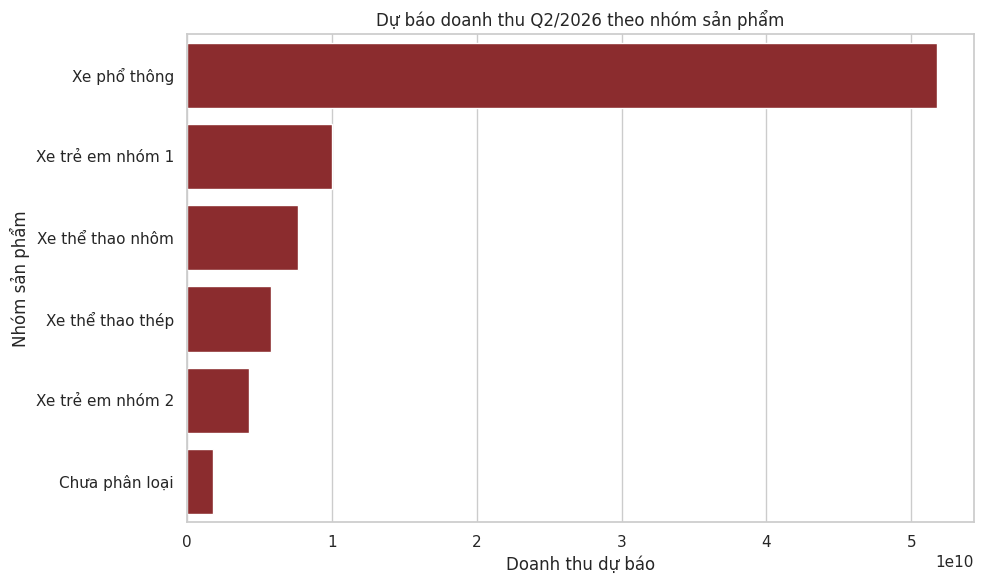

In [11]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=group_forecast,
    y="group_name_final",
    x="forecast_q2_revenue",
    color="#9b1c1f"
)

plt.title("Dự báo doanh thu Q2/2026 theo nhóm sản phẩm")
plt.xlabel("Doanh thu dự báo")
plt.ylabel("Nhóm sản phẩm")
plt.tight_layout()
plt.show()

In [12]:
color_q1_2026 = (
    q1_2026.groupby("color", dropna=False)
    .agg(
        q1_quantity=("quantity", "sum"),
        q1_revenue=("line_total", "sum")
    )
    .reset_index()
)

color_q1_2025 = (
    q1_2025.groupby("color", dropna=False)
    .agg(
        q1_2025_quantity=("quantity", "sum"),
        q1_2025_revenue=("line_total", "sum")
    )
    .reset_index()
)

color_forecast = color_q1_2026.merge(color_q1_2025, on="color", how="left")

color_forecast[["q1_2025_quantity", "q1_2025_revenue"]] = (
    color_forecast[["q1_2025_quantity", "q1_2025_revenue"]].fillna(0)
)

color_forecast["q1_2026_share"] = (
    color_forecast["q1_quantity"] / color_forecast["q1_quantity"].sum()
)

color_forecast["q1_2025_share"] = (
    color_forecast["q1_2025_quantity"] / color_forecast["q1_2025_quantity"].sum()
)

color_forecast["share_change"] = (
    color_forecast["q1_2026_share"] - color_forecast["q1_2025_share"]
)

color_forecast["forecast_q2_quantity"] = color_forecast["q1_quantity"]
color_forecast["forecast_q2_revenue"] = color_forecast["q1_revenue"]

color_forecast["forecast_share"] = (
    color_forecast["forecast_q2_quantity"]
    / color_forecast["forecast_q2_quantity"].sum()
)

color_forecast["trend"] = np.select(
    [
        color_forecast["share_change"] > 0.01,
        color_forecast["share_change"] < -0.01
    ],
    ["TĂNG", "GIẢM"],
    default="ỔN ĐỊNH"
)

color_forecast["slow_color_risk"] = np.where(
    (color_forecast["q1_quantity"] < 100)
    | (color_forecast["share_change"] < -0.02),
    "HIGH",
    "LOW"
)

color_forecast = color_forecast.sort_values(
    "forecast_q2_quantity",
    ascending=False
)

display(
    color_forecast[
        [
            "color",
            "q1_quantity",
            "q1_2025_quantity",
            "forecast_q2_quantity",
            "forecast_share",
            "share_change",
            "trend",
            "slow_color_risk"
        ]
    ].head(20)
)

,color,q1_quantity,q1_2025_quantity,forecast_q2_quantity,forecast_share,share_change,trend,slow_color_risk
7,Kem,8827.0,3002.0,8827.0,0.174206,0.034409,TĂNG,LOW
27,Đen,7813.0,2951.0,7813.0,0.154194,0.016772,TĂNG,LOW
4,Ghi,5806.0,1747.0,5806.0,0.114585,0.033230,TĂNG,LOW
5,Hồng,4992.0,1754.0,4992.0,0.098520,0.016840,TĂNG,LOW
12,Trắng,3851.0,1635.0,3851.0,0.076002,-0.000137,ỔN ĐỊNH,LOW
18,Xanh,3647.0,838.0,3647.0,0.071976,0.032952,TĂNG,LOW
1,Café/nâu,2718.0,1528.0,2718.0,0.053641,-0.017515,GIẢM,LOW
28,Đỏ,1996.0,657.0,1996.0,0.039392,0.008797,ỔN ĐỊNH,LOW
8,Không xác định,1507.0,1102.0,1507.0,0.029741,-0.021576,GIẢM,HIGH
22,Xanh dương,1468.0,1789.0,1468.0,0.028972,-0.054338,GIẢM,HIGH


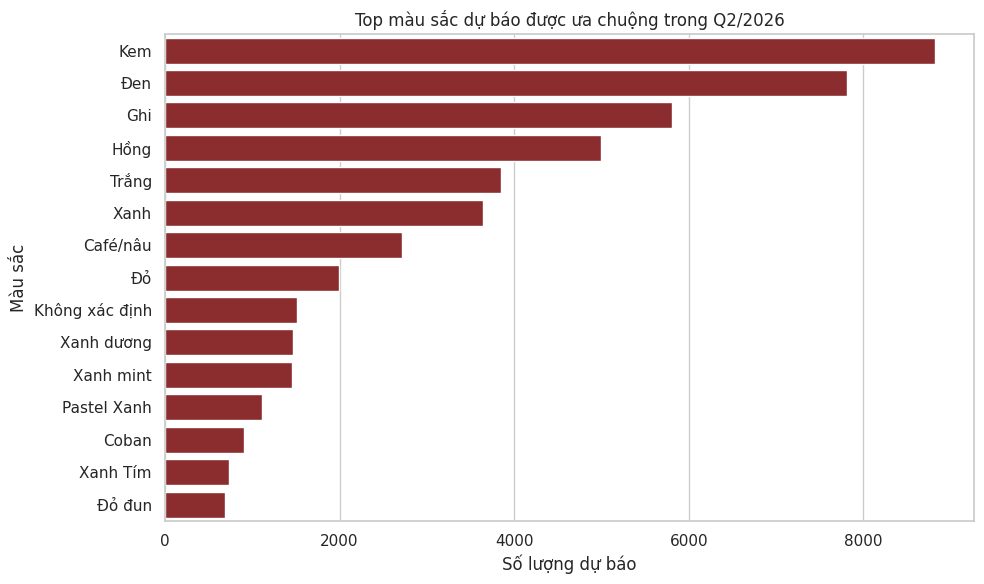

In [13]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=color_forecast.head(15),
    x="forecast_q2_quantity",
    y="color",
    color="#9b1c1f"
)

plt.title("Top màu sắc dự báo được ưa chuộng trong Q2/2026")
plt.xlabel("Số lượng dự báo")
plt.ylabel("Màu sắc")
plt.tight_layout()
plt.show()

In [14]:
as_of_date = pd.Timestamp("2026-03-31")

dealer = (
    df[df["customer_code_final"] != "UNKNOWN"]
    .groupby(["customer_code_final", "customer_name_final"], dropna=False)
    .agg(
        last_order_date=("order_date", "max"),
        frequency=("so_number", "nunique"),
        monetary=("line_total", "sum"),
        quantity=("quantity", "sum")
    )
    .reset_index()
)

dealer["recency_days"] = (as_of_date - dealer["last_order_date"]).dt.days

dealer["recency_score"] = pd.qcut(
    dealer["recency_days"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

dealer["frequency_score"] = pd.qcut(
    dealer["frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

dealer["monetary_score"] = pd.qcut(
    dealer["monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

dealer["rfm_score"] = (
    dealer["recency_score"] * 0.4
    + dealer["frequency_score"] * 0.3
    + dealer["monetary_score"] * 0.3
)

dealer_yoy = (
    df[df["customer_code_final"] != "UNKNOWN"]
    .groupby(["customer_code_final", "year"])
    .agg(
        orders=("so_number", "nunique"),
        revenue=("line_total", "sum")
    )
    .reset_index()
    .pivot(index="customer_code_final", columns="year", values=["orders", "revenue"])
    .fillna(0)
)

dealer_yoy.columns = [f"{a}_{b}" for a, b in dealer_yoy.columns]
dealer = dealer.merge(dealer_yoy, on="customer_code_final", how="left").fillna(0)

dealer["dealer_yoy_rev"] = np.where(
    dealer["revenue_2025"] > 0,
    dealer["revenue_2026"] / dealer["revenue_2025"] - 1,
    np.nan
)

dealer["recency_component"] = np.exp(-dealer["recency_days"] / 30)
dealer["frequency_component"] = dealer["frequency"].rank(pct=True)
dealer["monetary_component"] = dealer["monetary"].rank(pct=True)
dealer["active_2026_component"] = np.where(dealer["orders_2026"] > 0, 1, 0)
dealer["yoy_component"] = dealer["dealer_yoy_rev"].clip(-1, 1).fillna(0)
dealer["yoy_component"] = (dealer["yoy_component"] + 1) / 2

dealer["order_prob_30d"] = (
    0.35 * dealer["recency_component"]
    + 0.25 * dealer["frequency_component"]
    + 0.20 * dealer["monetary_component"]
    + 0.10 * dealer["active_2026_component"]
    + 0.10 * dealer["yoy_component"]
).clip(0.02, 0.99)

dealer["priority_tier"] = pd.qcut(
    dealer["order_prob_30d"].rank(method="first"),
    4,
    labels=["D - Low", "C - Medium", "B - High", "A - Top"]
)

dealer["churn_risk"] = np.select(
    [
        (dealer["recency_days"] > 90) & ((dealer["orders_2026"] == 0) | (dealer["dealer_yoy_rev"] < -0.3)),
        (dealer["recency_days"] > 45) | (dealer["dealer_yoy_rev"] < -0.3)
    ],
    ["HIGH", "MEDIUM"],
    default="LOW"
)

dealer_propensity = dealer.sort_values("order_prob_30d", ascending=False)

display(dealer_propensity.head(20))

,customer_code_final,customer_name_final,last_order_date,frequency,monetary,quantity,recency_days,recency_score,frequency_score,monetary_score,...,revenue_2026,dealer_yoy_rev,recency_component,frequency_component,monetary_component,active_2026_component,yoy_component,order_prob_30d,priority_tier,churn_risk
23,KH-00024,CÔNG TY TNHH MINH PHƯƠNG,2026-03-31,21,9.708788e+08,637.0,0,5,5,5,...,7.044488e+08,1.644030,1.000000,0.988604,0.985755,1,1.000000,0.990000,A - Top,LOW
26,KH-00027,HỘ KINH DOANH ĐẠI DƯƠNG,2026-03-31,22,7.369027e+08,434.0,0,5,5,5,...,6.686354e+08,8.794380,1.000000,0.991453,0.970085,1,1.000000,0.990000,A - Top,LOW
90,KH-00091,CÔNG TY TNHH BÌNH MINH,2026-03-31,55,9.586955e+09,8115.0,0,5,5,5,...,6.898346e+09,1.565767,1.000000,0.994302,1.000000,1,1.000000,0.990000,A - Top,LOW
146,KH-00147,CÔNG TY TNHH PHÚ THỊNH,2026-03-31,24,1.073408e+09,748.0,0,5,5,5,...,8.970094e+08,4.085138,1.000000,0.992877,0.990028,1,1.000000,0.990000,A - Top,LOW
156,KH-00157,CÔNG TY TNHH THƯƠNG MẠI LONG PHÚ,2026-03-31,137,4.919810e+08,206.0,0,5,5,5,...,4.849624e+08,68.097547,1.000000,1.000000,0.947293,1,1.000000,0.989459,A - Top,LOW
134,KH-00135,CỬA HÀNG XE ĐẠP XUÂN MAI,2026-03-31,92,2.647277e+08,168.0,0,5,5,5,...,2.305477e+08,5.745106,1.000000,0.998575,0.871795,1,1.000000,0.974003,A - Top,LOW
17,KH-00018,CÔNG TY TNHH THƯƠNG MẠI PHÚ THỊNH,2026-03-29,14,4.896307e+08,352.0,2,5,5,5,...,3.637293e+08,1.888999,0.935507,0.977920,0.944444,1,1.000000,0.960796,A - Top,LOW
249,KH-00250,DOANH NGHIỆP TW XUÂN MAI,2026-03-31,6,7.412493e+08,390.0,0,5,5,5,...,6.452778e+08,5.723641,1.000000,0.856838,0.971510,1,1.000000,0.958511,A - Top,LOW
10,KH-00011,DOANH NGHIỆP TW NAM TIẾN,2026-03-31,6,3.494304e+08,193.0,0,5,5,5,...,3.448193e+08,73.780068,1.000000,0.856838,0.908832,1,1.000000,0.945976,A - Top,LOW
18,KH-00019,CÔNG TY CỔ PHẦN THƯƠNG MẠI LÊ ANH,2026-03-26,70,4.483061e+09,2266.0,5,5,5,5,...,3.167559e+09,1.407870,0.846482,0.995726,0.998575,1,1.000000,0.944915,A - Top,LOW


In [15]:
dealer["monetary_pct_rank"] = dealer["monetary"].rank(pct=True)
dealer["is_high_value"] = dealer["monetary_pct_rank"] >= 0.80
dealer["q1_active_silent_60d"] = (
    (dealer["orders_2026"] > 0)
    & (dealer["recency_days"] >= 60)
)

dealer["churn_risk"] = np.select(
    [
        (dealer["recency_days"] >= 60) & dealer["is_high_value"],
        dealer["q1_active_silent_60d"] & (dealer["monetary_pct_rank"] >= 0.50),
        (dealer["recency_days"] >= 60) & ~dealer["is_high_value"] & ~dealer["q1_active_silent_60d"],
        dealer["recency_days"].between(30, 59)
    ],
    ["HIGH", "HIGH", "MEDIUM", "MEDIUM"],
    default="LOW"
)

def assign_dealer_segment(row):
    if row["recency_score"] >= 4 and row["frequency_score"] >= 4 and row["monetary_score"] >= 4:
        return "VIP / Chiến lược"
    if row["churn_risk"] == "HIGH":
        return "Giá trị cao nhưng giảm hoạt động"
    if row["recency_score"] >= 4 and row["frequency_score"] >= 3:
        return "Đang hoạt động / trung thành"
    if row["recency_score"] >= 4 and row["monetary_score"] <= 3:
        return "Mới mua gần đây / có tiềm năng"
    if row["recency_days"] >= 60 and row["monetary_score"] <= 2 and row["frequency_score"] <= 2:
        return "Ít hoạt động / giá trị thấp"
    if row["dealer_yoy_rev"] > 0.30:
        return "Tăng trưởng"
    return "Theo dõi thêm"

dealer["dealer_segment"] = dealer.apply(assign_dealer_segment, axis=1)

def assign_action(row):
    if row["dealer_segment"] == "VIP / Chiến lược":
        return "Duy trì chăm sóc riêng, ưu tiên hàng bán chạy"
    if row["dealer_segment"] == "Giá trị cao nhưng giảm hoạt động":
        return "Liên hệ tái kích hoạt trong 7 ngày"
    if row["dealer_segment"] == "Đang hoạt động / trung thành":
        return "Duy trì nhịp đặt hàng, gợi ý bán thêm"
    if row["dealer_segment"] == "Mới mua gần đây / có tiềm năng":
        return "Đề xuất combo sản phẩm để tăng đơn hàng"
    if row["dealer_segment"] == "Ít hoạt động / giá trị thấp":
        return "Ưu tiên thấp, chăm sóc tự động"
    if row["dealer_segment"] == "Tăng trưởng":     
        return "Duy trì đà tăng, ưu tiên sản phẩm chiến lược"
    return "Theo dõi thêm"

dealer["recommended_action"] = dealer.apply(assign_action, axis=1)

dealer["risk_reason"] = np.select(
    [
        dealer["q1_active_silent_60d"] & dealer["is_high_value"],
        dealer["q1_active_silent_60d"],
        (dealer["recency_days"] >= 60) & dealer["is_high_value"],
        dealer["recency_days"].between(30, 59)
    ],
    [
        "Từng mua Q1/2026 nhưng im lặng >= 60 ngày — doanh thu lịch sử cao",
        "Từng mua trong Q1/2026 nhưng im lặng từ 60 ngày trở lên",
        "Doanh thu lịch sử cao nhưng đã lâu chưa mua",
        "Bắt đầu có dấu hiệu giảm nhịp mua"
    ],
    default="Đang hoạt động hoặc rủi ro thấp"
)

dealer["priority_reason"] = (
    "R=" + dealer["recency_score"].astype(str)
    + ", F=" + dealer["frequency_score"].astype(str)
    + ", M=" + dealer["monetary_score"].astype(str)
    + ", score=" + dealer["order_prob_30d"].round(2).astype(str)
)

dealer_propensity = dealer.sort_values("order_prob_30d", ascending=False)
risk_dealer_full = (
    dealer[dealer["churn_risk"].isin(["HIGH", "MEDIUM"])]
    .sort_values(["churn_risk", "monetary"], ascending=[True, False])
)

display(dealer_propensity.head(20))
display(risk_dealer_full.head(20))

,customer_code_final,customer_name_final,last_order_date,frequency,monetary,quantity,recency_days,recency_score,frequency_score,monetary_score,...,order_prob_30d,priority_tier,churn_risk,monetary_pct_rank,is_high_value,q1_active_silent_60d,dealer_segment,recommended_action,risk_reason,priority_reason
23,KH-00024,CÔNG TY TNHH MINH PHƯƠNG,2026-03-31,21,9.708788e+08,637.0,0,5,5,5,...,0.990000,A - Top,LOW,0.985755,True,False,VIP / Chiến lược,"Duy trì chăm sóc riêng, ưu tiên hàng bán chạy",Đang hoạt động hoặc rủi ro thấp,"R=5, F=5, M=5, score=0.99"
26,KH-00027,HỘ KINH DOANH ĐẠI DƯƠNG,2026-03-31,22,7.369027e+08,434.0,0,5,5,5,...,0.990000,A - Top,LOW,0.970085,True,False,VIP / Chiến lược,"Duy trì chăm sóc riêng, ưu tiên hàng bán chạy",Đang hoạt động hoặc rủi ro thấp,"R=5, F=5, M=5, score=0.99"
90,KH-00091,CÔNG TY TNHH BÌNH MINH,2026-03-31,55,9.586955e+09,8115.0,0,5,5,5,...,0.990000,A - Top,LOW,1.000000,True,False,VIP / Chiến lược,"Duy trì chăm sóc riêng, ưu tiên hàng bán chạy",Đang hoạt động hoặc rủi ro thấp,"R=5, F=5, M=5, score=0.99"
146,KH-00147,CÔNG TY TNHH PHÚ THỊNH,2026-03-31,24,1.073408e+09,748.0,0,5,5,5,...,0.990000,A - Top,LOW,0.990028,True,False,VIP / Chiến lược,"Duy trì chăm sóc riêng, ưu tiên hàng bán chạy",Đang hoạt động hoặc rủi ro thấp,"R=5, F=5, M=5, score=0.99"
156,KH-00157,CÔNG TY TNHH THƯƠNG MẠI LONG PHÚ,2026-03-31,137,4.919810e+08,206.0,0,5,5,5,...,0.989459,A - Top,LOW,0.947293,True,False,VIP / Chiến lược,"Duy trì chăm sóc riêng, ưu tiên hàng bán chạy",Đang hoạt động hoặc rủi ro thấp,"R=5, F=5, M=5, score=0.99"
134,KH-00135,CỬA HÀNG XE ĐẠP XUÂN MAI,2026-03-31,92,2.647277e+08,168.0,0,5,5,5,...,0.974003,A - Top,LOW,0.871795,True,False,VIP / Chiến lược,"Duy trì chăm sóc riêng, ưu tiên hàng bán chạy",Đang hoạt động hoặc rủi ro thấp,"R=5, F=5, M=5, score=0.97"
17,KH-00018,CÔNG TY TNHH THƯƠNG MẠI PHÚ THỊNH,2026-03-29,14,4.896307e+08,352.0,2,5,5,5,...,0.960796,A - Top,LOW,0.944444,True,False,VIP / Chiến lược,"Duy trì chăm sóc riêng, ưu tiên hàng bán chạy",Đang hoạt động hoặc rủi ro thấp,"R=5, F=5, M=5, score=0.96"
249,KH-00250,DOANH NGHIỆP TW XUÂN MAI,2026-03-31,6,7.412493e+08,390.0,0,5,5,5,...,0.958511,A - Top,LOW,0.971510,True,False,VIP / Chiến lược,"Duy trì chăm sóc riêng, ưu tiên hàng bán chạy",Đang hoạt động hoặc rủi ro thấp,"R=5, F=5, M=5, score=0.96"
10,KH-00011,DOANH NGHIỆP TW NAM TIẾN,2026-03-31,6,3.494304e+08,193.0,0,5,5,5,...,0.945976,A - Top,LOW,0.908832,True,False,VIP / Chiến lược,"Duy trì chăm sóc riêng, ưu tiên hàng bán chạy",Đang hoạt động hoặc rủi ro thấp,"R=5, F=5, M=5, score=0.95"
18,KH-00019,CÔNG TY CỔ PHẦN THƯƠNG MẠI LÊ ANH,2026-03-26,70,4.483061e+09,2266.0,5,5,5,5,...,0.944915,A - Top,LOW,0.998575,True,False,VIP / Chiến lược,"Duy trì chăm sóc riêng, ưu tiên hàng bán chạy",Đang hoạt động hoặc rủi ro thấp,"R=5, F=5, M=5, score=0.94"


,customer_code_final,customer_name_final,last_order_date,frequency,monetary,quantity,recency_days,recency_score,frequency_score,monetary_score,...,order_prob_30d,priority_tier,churn_risk,monetary_pct_rank,is_high_value,q1_active_silent_60d,dealer_segment,recommended_action,risk_reason,priority_reason
172,KH-00173,DOANH NGHIỆP TW PHÚ THỊNH,2025-03-25,21,1.582008e+09,740.0,371,1,5,5,...,0.446583,C - Medium,HIGH,0.997151,True,False,Giá trị cao nhưng giảm hoạt động,Liên hệ tái kích hoạt trong 7 ngày,Doanh thu lịch sử cao nhưng đã lâu chưa mua,"R=1, F=5, M=5, score=0.45"
56,KH-00057,CÔNG TY CỔ PHẦN THƯƠNG MẠI TOÀN THẮNG,2025-03-29,5,5.635752e+08,499.0,367,2,4,5,...,0.393128,C - Medium,HIGH,0.958689,True,False,Giá trị cao nhưng giảm hoạt động,Liên hệ tái kích hoạt trong 7 ngày,Doanh thu lịch sử cao nhưng đã lâu chưa mua,"R=2, F=4, M=5, score=0.39"
74,KH-00075,CÔNG TY CỔ PHẦN ĐÔNG NAM,2026-01-26,7,3.676276e+08,272.0,64,2,5,5,...,0.557972,B - High,HIGH,0.918803,True,True,Giá trị cao nhưng giảm hoạt động,Liên hệ tái kích hoạt trong 7 ngày,Từng mua Q1/2026 nhưng im lặng >= 60 ngày — do...,"R=2, F=5, M=5, score=0.56"
131,KH-00132,CÔNG TY TNHH THƯƠNG MẠI HOÀ BÌNH,2025-03-28,4,3.416500e+08,287.0,368,2,4,5,...,0.362644,C - Medium,HIGH,0.905983,True,False,Giá trị cao nhưng giảm hoạt động,Liên hệ tái kích hoạt trong 7 ngày,Doanh thu lịch sử cao nhưng đã lâu chưa mua,"R=2, F=4, M=5, score=0.36"
97,KH-00098,HỘ KINH DOANH MẶT TRỜI,2025-03-18,3,3.024800e+08,260.0,378,1,3,5,...,0.328812,C - Medium,HIGH,0.891738,True,False,Giá trị cao nhưng giảm hoạt động,Liên hệ tái kích hoạt trong 7 ngày,Doanh thu lịch sử cao nhưng đã lâu chưa mua,"R=1, F=3, M=5, score=0.33"
39,KH-00040,CÔNG TY TNHH VẠN LỢI,2025-03-29,3,2.934000e+08,163.0,367,2,3,5,...,0.327958,C - Medium,HIGH,0.887464,True,False,Giá trị cao nhưng giảm hoạt động,Liên hệ tái kích hoạt trong 7 ngày,Doanh thu lịch sử cao nhưng đã lâu chưa mua,"R=2, F=3, M=5, score=0.33"
490,KH-00491,CÔNG TY TNHH PHÚC AN,2026-01-28,2,2.830266e+08,178.0,62,2,3,5,...,0.477076,C - Medium,HIGH,0.883191,True,True,Giá trị cao nhưng giảm hoạt động,Liên hệ tái kích hoạt trong 7 ngày,Từng mua Q1/2026 nhưng im lặng >= 60 ngày — do...,"R=2, F=3, M=5, score=0.48"
333,KH-00334,HỘ KINH DOANH YÊN BÌNH,2026-01-06,2,2.448056e+08,170.0,84,2,3,5,...,0.449204,C - Medium,HIGH,0.858974,True,True,Giá trị cao nhưng giảm hoạt động,Liên hệ tái kích hoạt trong 7 ngày,Từng mua Q1/2026 nhưng im lặng >= 60 ngày — do...,"R=2, F=3, M=5, score=0.45"
192,KH-00193,CÔNG TY TNHH TÚ ANH,2025-03-31,4,2.447659e+08,204.0,365,2,4,5,...,0.352958,C - Medium,HIGH,0.857550,True,False,Giá trị cao nhưng giảm hoạt động,Liên hệ tái kích hoạt trong 7 ngày,Doanh thu lịch sử cao nhưng đã lâu chưa mua,"R=2, F=4, M=5, score=0.35"
276,KH-00277,CÔNG TY CỔ PHẦN THƯƠNG MẠI VĨNH PHÁT,2025-03-25,2,2.324900e+08,200.0,371,1,3,5,...,0.276782,C - Medium,HIGH,0.853276,True,False,Giá trị cao nhưng giảm hoạt động,Liên hệ tái kích hoạt trong 7 ngày,Doanh thu lịch sử cao nhưng đã lâu chưa mua,"R=1, F=3, M=5, score=0.28"


In [16]:
seg_summary = dealer.groupby("dealer_segment").agg(
    so_dai_ly=("customer_code_final", "count"),
    median_monetary=("monetary", "median"),
    pct_high_risk=("churn_risk", lambda x: (x == "HIGH").mean())
).round(2)

risk_summary = dealer["churn_risk"].value_counts()
tier_summary = dealer["priority_tier"].value_counts()

total_q1 = q1_2026["line_total"].sum()
recency_60_dealers = dealer[dealer["recency_days"] >= 60]
recency_60_q1_revenue = recency_60_dealers["revenue_2026"].sum()
q1_active_silent = dealer[dealer["q1_active_silent_60d"]]

print("=== SEGMENT SUMMARY ===")
display(seg_summary)

print("\n=== CHURN RISK ===")
display(risk_summary)

print("\n=== PRIORITY TIER ===")
display(tier_summary)

print(f"\nĐại lý recency >= 60 ngày: {len(recency_60_dealers):,}")
print(f"Tỷ lệ trên tổng mạng lưới: {len(recency_60_dealers) / len(dealer):.1%}")
print(f"Doanh thu Q1/2026 của nhóm recency >= 60: {recency_60_q1_revenue:,.0f}")
print(f"Tỷ trọng doanh thu Q1/2026: {recency_60_q1_revenue / total_q1:.2%}")
print(f"Q1-active nhưng im lặng >= 60 ngày: {len(q1_active_silent):,}")

=== SEGMENT SUMMARY ===


,so_dai_ly,median_monetary,pct_high_risk
dealer_segment,,,
Giá trị cao nhưng giảm hoạt động,19,232490000.0,1.0
Mới mua gần đây / có tiềm năng,7,48772963.0,0.0
Theo dõi thêm,213,68250264.0,0.0
Tăng trưởng,10,154295573.5,0.0
VIP / Chiến lược,174,204358703.0,0.0
Ít hoạt động / giá trị thấp,179,23300000.0,0.0
Đang hoạt động / trung thành,100,72597160.0,0.0



=== CHURN RISK ===


churn_risk
LOW       389
MEDIUM    294
HIGH       19
Name: count, dtype: int64


=== PRIORITY TIER ===


priority_tier
D - Low       176
A - Top       176
C - Medium    175
B - High      175
Name: count, dtype: int64


Đại lý recency >= 60 ngày: 280
Tỷ lệ trên tổng mạng lưới: 39.9%
Doanh thu Q1/2026 của nhóm recency >= 60: 1,912,226,729
Tỷ trọng doanh thu Q1/2026: 2.35%
Q1-active nhưng im lặng >= 60 ngày: 48


In [17]:
# Kiểm chứng claim: đại lý không mua lại >= 60 ngày và tỷ trọng doanh thu Q1/2026

as_of_date = pd.Timestamp("2026-03-31")

q1_2026 = df[df["year"] == 2026].copy()

dealer_last = (
    df[df["customer_code_final"] != "UNKNOWN"]
    .groupby(["customer_code_final", "customer_name_final"], dropna=False)
    .agg(
        last_order_date=("order_date", "max"),
        total_revenue_all=("line_total", "sum"),
        total_orders_all=("so_number", "nunique")
    )
    .reset_index()
)

dealer_last["recency_days"] = (
    as_of_date - dealer_last["last_order_date"]
).dt.days

q1_rev_by_dealer = (
    q1_2026[q1_2026["customer_code_final"] != "UNKNOWN"]
    .groupby("customer_code_final", dropna=False)
    .agg(
        q1_2026_revenue=("line_total", "sum"),
        q1_2026_orders=("so_number", "nunique"),
        q1_2026_quantity=("quantity", "sum")
    )
    .reset_index()
)

dealer_check = dealer_last.merge(
    q1_rev_by_dealer,
    on="customer_code_final",
    how="left"
).fillna({
    "q1_2026_revenue": 0,
    "q1_2026_orders": 0,
    "q1_2026_quantity": 0
})

total_q1_revenue = q1_2026["line_total"].sum()

# Cách hiểu 1: tất cả đại lý trong dataset có recency >= 60 ngày
at_risk_60_all = dealer_check[dealer_check["recency_days"] >= 60].copy()

# Cách hiểu 2: chỉ tính đại lý có phát sinh trong Q1/2026 nhưng đến 31/03/2026 đã >= 60 ngày chưa mua lại
at_risk_60_q1_buyers = dealer_check[
    (dealer_check["recency_days"] >= 60)
    & (dealer_check["q1_2026_revenue"] > 0)
].copy()

summary_check = pd.DataFrame({
    "case": [
        "All dealers recency >= 60",
        "Q1/2026 buyers recency >= 60"
    ],
    "dealer_count": [
        len(at_risk_60_all),
        len(at_risk_60_q1_buyers)
    ],
    "q1_2026_revenue": [
        at_risk_60_all["q1_2026_revenue"].sum(),
        at_risk_60_q1_buyers["q1_2026_revenue"].sum()
    ],
    "q1_2026_revenue_pct": [
        at_risk_60_all["q1_2026_revenue"].sum() / total_q1_revenue,
        at_risk_60_q1_buyers["q1_2026_revenue"].sum() / total_q1_revenue
    ]
})

display(summary_check)

display(
    at_risk_60_q1_buyers
    .sort_values("q1_2026_revenue", ascending=False)
    .head(20)
)

,case,dealer_count,q1_2026_revenue,q1_2026_revenue_pct
0,All dealers recency >= 60,280,1.912227e+09,0.023513
1,Q1/2026 buyers recency >= 60,48,1.912227e+09,0.023513


,customer_code_final,customer_name_final,last_order_date,total_revenue_all,total_orders_all,recency_days,q1_2026_revenue,q1_2026_orders,q1_2026_quantity
490,KH-00491,CÔNG TY TNHH PHÚC AN,2026-01-28,283026601.0,2,62,283026601.0,2.0,178.0
333,KH-00334,HỘ KINH DOANH YÊN BÌNH,2026-01-06,244805554.0,2,84,244805554.0,2.0,170.0
426,KH-00427,CÔNG TY CỔ PHẦN THƯƠNG MẠI TÚ ANH,2026-01-24,110648148.0,1,66,110648148.0,1.0,50.0
498,KH-00499,CÔNG TY CỔ PHẦN THƯƠNG MẠI TÚ ANH,2026-01-27,96427756.0,1,63,96427756.0,1.0,51.0
405,KH-00406,CÔNG TY CỔ PHẦN THƯƠNG MẠI LONG PHÚ,2026-01-22,82642778.0,1,68,82642778.0,1.0,50.0
420,KH-00421,DOANH NGHIỆP TW YÊN BÌNH,2026-01-23,75644986.0,1,67,75644986.0,1.0,40.0
339,KH-00340,CÔNG TY TNHH THANH BÌNH,2026-01-26,74108412.0,3,64,74108412.0,3.0,48.0
393,KH-00394,CÔNG TY TNHH THƯƠNG MẠI NAM TIẾN,2026-01-19,71822204.0,1,71,71822204.0,1.0,45.0
519,KH-00520,CÔNG TY TNHH TÂY BẮC,2026-01-28,71704244.0,1,62,71704244.0,1.0,46.0
366,KH-00367,CÔNG TY CỔ PHẦN ĐÔNG NAM,2026-01-16,68896093.0,1,74,68896093.0,1.0,37.0


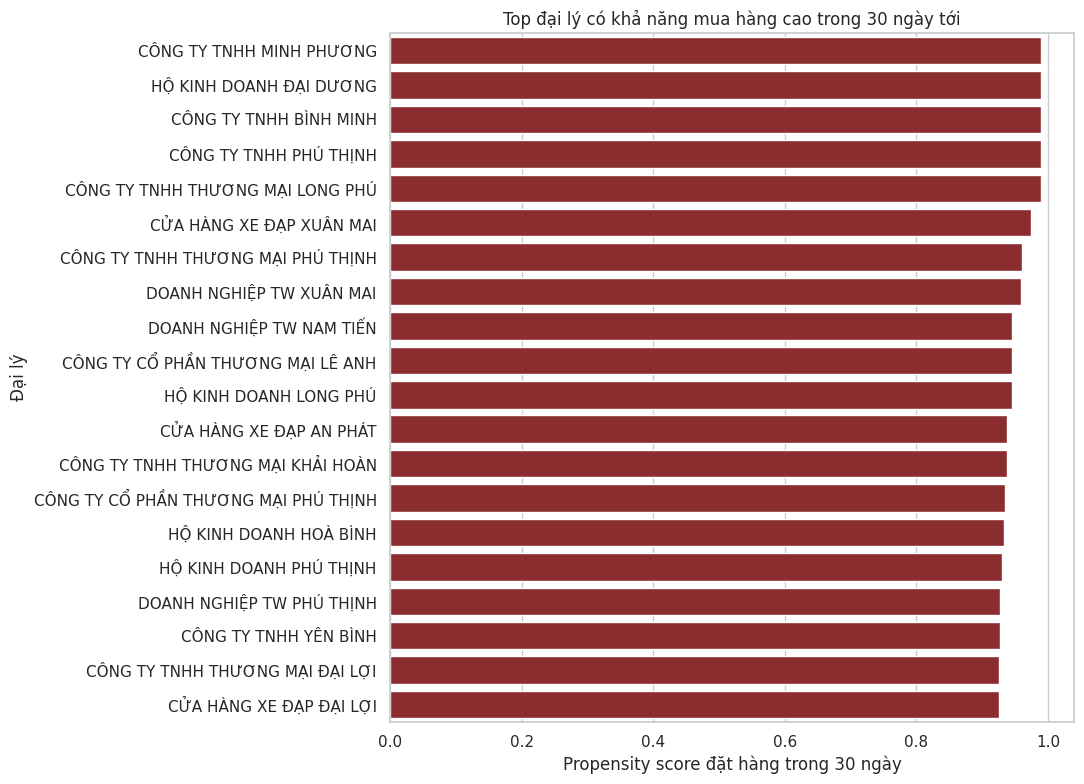

In [18]:
top_dealer_priority = dealer.sort_values("order_prob_30d", ascending=False).head(20)

plt.figure(figsize=(11, 8))

sns.barplot(
    data=top_dealer_priority,
    y="customer_name_final",
    x="order_prob_30d",
    color="#9b1c1f"
)

plt.title("Top đại lý có khả năng mua hàng cao trong 30 ngày tới")
plt.xlabel("Propensity score đặt hàng trong 30 ngày")
plt.ylabel("Đại lý")
plt.tight_layout()
plt.show()

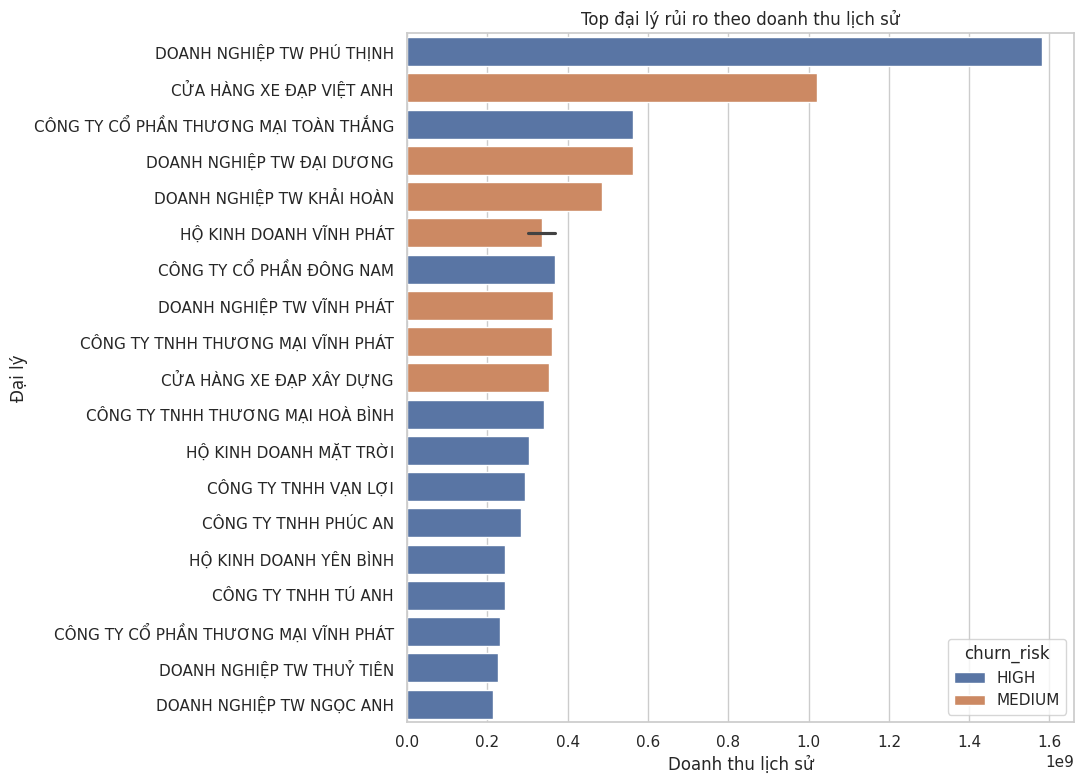

In [19]:
risk_dealer = (
    dealer[dealer["churn_risk"] != "LOW"]
    .sort_values("monetary", ascending=False)
    .head(20)
)

plt.figure(figsize=(11, 8))

sns.barplot(
    data=risk_dealer,
    y="customer_name_final",
    x="monetary",
    hue="churn_risk",
    dodge=False
)

plt.title("Top đại lý rủi ro theo doanh thu lịch sử")
plt.xlabel("Doanh thu lịch sử")
plt.ylabel("Đại lý")
plt.tight_layout()
plt.show()

In [20]:
OUT_DIR = Path("/kaggle/working/outputs")
OUT_DIR.mkdir(exist_ok=True)

forecast_q2_export = forecast_q2.rename(columns={
    "forecast_month": "Thang",
    "base_revenue": "DoanhThu",
    "base_quantity": "SoLuong"
})

forecast_q2_scenarios_export = forecast_q2.rename(columns={
    "forecast_month": "Thang",
    "conservative_revenue": "Conservative Revenue",
    "base_revenue": "Base Revenue",
    "optimistic_revenue": "Optimistic Revenue",
    "conservative_quantity": "Conservative Quantity",
    "base_quantity": "Base Quantity",
    "optimistic_quantity": "Optimistic Quantity"
})

forecast_q2_scenarios_export[
    [
        "Thang",
        "Conservative Revenue",
        "Base Revenue",
        "Optimistic Revenue",
        "Conservative Quantity",
        "Base Quantity",
        "Optimistic Quantity"
    ]
].to_csv(
    OUT_DIR / "forecast_q2_monthly_scenarios.csv",
    index=False,
    encoding="utf-8-sig"
)

forecast_q2_export[["Thang", "DoanhThu", "SoLuong"]].to_csv(
    OUT_DIR / "forecast_q2_monthly.csv",
    index=False,
    encoding="utf-8-sig"
)

forecast_by_group_export = group_forecast.rename(columns={
    "group_name_final": "NhomSP",
    "forecast_q2_revenue": "DoanhThu",
    "forecast_q2_quantity": "SoLuong"
})

forecast_by_group_export[["NhomSP", "DoanhThu", "SoLuong", "sku_count"]].to_csv(
    OUT_DIR / "forecast_q2_by_group.csv",
    index=False,
    encoding="utf-8-sig"
)

top20_sku_export = top20_sku.rename(columns={
    "product_code": "SKU",
    "product_name": "ProductName",
    "forecast_q2_revenue": "ForecastRevenue",
    "forecast_q2_quantity": "ForecastQuantity"
})

top20_sku_export[
    [
        "SKU",
        "ProductName",
        "line_name_final",
        "group_name_final",
        "ForecastRevenue",
        "ForecastQuantity",
        "sku_trend",
        "slow_mover_risk"
    ]
].to_csv(
    OUT_DIR / "forecast_top20_sku.csv",
    index=False,
    encoding="utf-8-sig"
)

slow_sku = sku_forecast[sku_forecast["slow_mover_risk"] == "HIGH"].copy()

slow_sku["recommended_action"] = np.where(
    slow_sku["yoy_qty_growth"] < -0.2,
    "Rà soát nhu cầu giảm, kiểm soát tồn kho trước khi sản xuất thêm",
    "Theo dõi thêm vì sản lượng thấp"
)

slow_sku[
    [
        "product_code",
        "product_name",
        "group_name_final",
        "color",
        "q1_2025_quantity",
        "q1_quantity",
        "yoy_qty_growth",
        "slow_mover_risk",
        "recommended_action"
    ]
].rename(columns={
    "q1_quantity": "q1_2026_quantity"
}).to_csv(
    OUT_DIR / "slow_moving_sku_risk.csv",
    index=False,
    encoding="utf-8-sig"
)

dealer_export = dealer_propensity.rename(columns={
    "customer_code_final": "customer_code",
    "customer_name_final": "customer_name",
    "recency_score": "R_score",
    "frequency_score": "F_score",
    "monetary_score": "M_score",
    "order_prob_30d": "purchase_priority_score"
})

dealer_export[
    [
        "customer_code",
        "customer_name",
        "recency_days",
        "frequency",
        "monetary",
        "R_score",
        "F_score",
        "M_score",
        "purchase_priority_score",
        "priority_tier",
        "churn_risk",
        "dealer_segment",
        "recommended_action",
        "risk_reason",
        "priority_reason"
    ]
].to_csv(
    OUT_DIR / "dealer_propensity_score.csv",
    index=False,
    encoding="utf-8-sig"
)

risk_dealer_export = risk_dealer_full.rename(columns={
    "customer_code_final": "customer_code",
    "customer_name_final": "customer_name",
    "recency_score": "R_score",
    "frequency_score": "F_score",
    "monetary_score": "M_score",
    "order_prob_30d": "purchase_priority_score"
})

risk_dealer_export[
    [
        "customer_code",
        "customer_name",
        "recency_days",
        "frequency",
        "monetary",
        "R_score",
        "F_score",
        "M_score",
        "purchase_priority_score",
        "priority_tier",
        "churn_risk",
        "dealer_segment",
        "recommended_action",
        "risk_reason",
        "priority_reason"
    ]
].to_csv(
    OUT_DIR / "dealer_churn_risk.csv",
    index=False,
    encoding="utf-8-sig"
)
color_forecast.to_csv(
    OUT_DIR / "forecast_color_and_slow_mover.csv",
    index=False,
    encoding="utf-8-sig"
)

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mape(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

group_2025 = (
    q1_2025.groupby("group_name_final")
    .agg(actual_2025=("line_total", "sum"))
    .reset_index()
)

group_2026 = (
    q1_2026.groupby("group_name_final")
    .agg(actual_2026=("line_total", "sum"))
    .reset_index()
)

bt = group_2026.merge(group_2025, on="group_name_final", how="left").fillna(0)

global_growth = rev_2026 / rev_2025

bt["pred_naive"] = bt["actual_2025"]
bt["pred_global_yoy"] = bt["actual_2025"] * global_growth

metrics = []

for model_col in ["pred_naive", "pred_global_yoy"]:
    y_true = bt["actual_2026"].values
    y_pred = bt[model_col].values

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape_value = mape(y_true, y_pred)
    
    metrics.append({
        "model": model_col,
        "level": "group_revenue",
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape_value
    })

metrics_df = pd.DataFrame(metrics)

display(bt)
display(metrics_df)

metrics_df.to_csv(
    OUT_DIR / "forecast_backtest_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

,group_name_final,actual_2026,actual_2025,pred_naive,pred_global_yoy
0,Chưa phân loại,2.557057e+09,3.408244e+08,3.408244e+08,9.858232e+08
1,Xe phổ thông,5.102672e+10,1.695689e+10,1.695689e+10,4.904725e+10
2,Xe thể thao nhôm,8.537671e+09,2.289778e+09,2.289778e+09,6.623108e+09
3,Xe thể thao thép,5.532914e+09,2.613696e+09,2.613696e+09,7.560028e+09
4,Xe trẻ em nhóm 1,1.000099e+10,4.016083e+09,4.016083e+09,1.161639e+10
5,Xe trẻ em nhóm 2,3.672639e+09,1.899900e+09,1.899900e+09,5.495397e+09


,model,level,MAE,RMSE,MAPE
0,pred_naive,group_revenue,8.868470e+09,1.444636e+10,64.582173
1,pred_global_yoy,group_revenue,1.821757e+09,1.830018e+09,31.695272


In [22]:
print("Đã cập nhật output lúc:", pd.Timestamp.now())
print("Danh sách output cuối:")
for p in sorted(OUT_DIR.iterdir()):
    print(p.name)

Đã cập nhật output lúc: 2026-05-27 08:48:34.181615
Danh sách output cuối:
dealer_churn_risk.csv
dealer_propensity_score.csv
forecast_backtest_metrics.csv
forecast_color_and_slow_mover.csv
forecast_q2_by_group.csv
forecast_q2_monthly.csv
forecast_q2_monthly_scenarios.csv
forecast_top20_sku.csv
slow_moving_sku_risk.csv


## Đánh giá mô hình

Do dữ liệu chỉ có 6 tháng, nhóm không đánh giá forecast bằng chuỗi thời gian dài. Thay vào đó, nhóm backtest ở cấp nhóm sản phẩm bằng cách so sánh Q1/2025 với Q1/2026.

Kết quả cho thấy mô hình global YoY tốt hơn baseline naive:
- Naive MAPE: 64.58%
- Global YoY MAPE: 31.70%

Điều này cho thấy việc sử dụng tăng trưởng YoY giúp cải thiện dự báo so với giả định giữ nguyên năm trước. Tuy nhiên, do dữ liệu không liên tục 15 tháng, kết quả forecast nên được dùng như công cụ hỗ trợ ra quyết định, không phải cam kết chính xác tuyệt đối.